# PyCBC CPU chi-square precision on real H1 search inputs

**The discrepancy persists in PyCBC 2.11.0, the latest stable PyPI release checked on 21 September 2026.** At the highlighted point, this execution gives χ² ≈ **43.05497** with complex64, versus **42.98097342** from an independent double-precision FFT: about **0.172%** difference. Explicit complex128 input reduces that difference to about **0.000500%**.

This replays the actual chi-square inputs captured from an ordinary CPU `pycbc_inspiral` qualification search of **public H1 detector strain**. It uses the saved correlation spectrum, SNR, normalization, frequency-bin edges and time indices. It does not rerun strain conditioning, template generation or the complete search. No JAX is imported or required.

**Run:** install `python -m pip install "pycbc==2.11.0" scipy matplotlib jupyterlab`, select that environment's kernel, then **Restart Kernel and Run All**. The notebook uses the accompanying 8 MB capture, or downloads the identical file from a pinned GitHub commit. A SHA-256 check verifies the bytes before loading. Download fallback needs internet; a checkout with the data works offline.

The [synthetic notebook](cpu_chisq_precision.ipynb) isolates the mechanism with an exact answer. This notebook tests whether the discrepancy also occurs on real search inputs.

In [1]:
import io
import hashlib
import platform
import warnings
from pathlib import Path
from urllib.request import urlopen

warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio")
import numpy as np
import scipy
from scipy.fft import ifft
import matplotlib.pyplot as plt
import pycbc
from pycbc.types import Array
from pycbc.scheme import CPUScheme
from pycbc.vetoes.chisq import power_chisq_at_points_from_precomputed

print(f"PyCBC {pycbc.__version__}; NumPy {np.__version__}; SciPy {scipy.__version__}")
print(f"Python {platform.python_version()}; {platform.system()} {platform.machine()}")
assert pycbc.__version__ == '2.11.0', 'Select a kernel with the tested PyCBC 2.11.0 release.'

PyCBC 2.11.0; NumPy 2.3.5; SciPy 1.16.3
Python 3.13.9; Darwin arm64


## 1. Load an unchanged capture from the real search

The 20 September qualification search used **32 distinct compressed IMRPhenomD templates**, H1 strain sampled at **2,048 Hz**, **512-second segments**, a **30 Hz cutoff**, and **16 equal-expected-power chi-square bins**. The channel was `H1:LOSC-STRAIN`; the source frame was `H-H1_LOSC_CLN_4_V1-1187007040-2048.gwf`. Search GPS bounds were 1187007048–1187009080.

The observer saved the first six calls by call order, containing 11 points. **Capture 5 is selected here because it contains the largest recorded CPU/FFT relative discrepancy among those 11 points.** We show all three points in this capture. The highlighted sample, 656106, did **not** survive the original NewSNR cut; it is not an additional detected event. This is an illustrative case, not a representative error distribution.

The original bytes and [provenance](https://github.com/xangma/pycbc/blob/7961bd498fa8abbd6f8909cc5ebdff750cbe8fe5/examples/numerics/data/point-input-05.json) are included with the notebook. They match the original report's [input manifest](https://github.com/xangma/pycbc/blob/e8b63f56ea444dca7b5ead91ca3a34da7398e3b5/docs/_static/jax_chisq_numerics/manifest.json).

In [2]:
filename = 'point-input-05.npz'
expected_sha256 = '1b824a1b7887634d8fce7e3a7c356972f417686a2a9924b59413d262592d67ce'
data_url = ('https://raw.githubusercontent.com/xangma/pycbc/'
            '7961bd498fa8abbd6f8909cc5ebdff750cbe8fe5/examples/numerics/data/' + filename)
candidates = [Path('data') / filename, Path('examples/numerics/data') / filename]
local_file = next((p for p in candidates if p.is_file()), None)
if local_file is not None:
    payload = local_file.read_bytes()
else:
    with urlopen(data_url, timeout=60) as response:
        payload = response.read()
assert hashlib.sha256(payload).hexdigest() == expected_sha256
with np.load(io.BytesIO(payload), allow_pickle=False) as saved:
    corr = saved['corr']
    snr = saved['snr']
    norm = float(saved['norm'])
    bins = saved['bins']
    points = saved['indices']

N = len(corr)
p = len(bins) - 1
sample_rate = 2048
segment_seconds = N / sample_rate
widths = np.diff(bins)
assert corr.dtype == np.complex64 and snr.dtype == np.complex64
assert N == 2**20 and p == 16 and np.all(widths > 0)
assert np.all(np.isfinite(corr)) and np.all(points < N)
print(f'Verified {filename}: {len(payload):,} bytes')
print(f'N = {N:,}; segment = {segment_seconds:g} s; frequency spacing = {1/segment_seconds:g} Hz')
print('Selected time samples:', points.tolist())
print('Frequency samples per chi-square bin:', widths.tolist())
print(f'Widest bin: {widths.max():,} samples; {widths.max()-1:,} rotations before its final coefficient')

Verified point-input-05.npz: 8,390,014 bytes
N = 1,048,576; segment = 512 s; frequency spacing = 0.00195312 Hz
Selected time samples: [484954, 619888, 656106]
Frequency samples per chi-square bin: [9156, 4750, 5023, 5126, 4290, 4627, 4359, 4951, 6051, 6467, 7951, 9583, 12507, 17611, 33168, 373308]
Widest bin: 373,308 samples; 373,307 rotations before its final coefficient


## 2. Run the installed PyCBC CPU calculation

Call PyCBC's public selected-point chi-square function under `CPUScheme`. Both calls use identical captured values. The second explicitly promotes the correlation to complex128, which preserves every stored complex64 value exactly; the captured SNR and normalization stay fixed.

PyCBC forms **χ² = (p × Σ |qᵦ|² − |snr|²) × norm²**, where qᵦ is the unnormalized Fourier sum for one bin. The complex64 CPU path stores its recurrent phase and sums at single precision. The recurrence restarts at each bin boundary, not at every frequency sample.

In [3]:
chisq_cpu = {}
with CPUScheme():
    for dtype in (np.complex64, np.complex128):
        value = power_chisq_at_points_from_precomputed(
            Array(corr.astype(dtype)), snr, norm, bins, points)
        chisq_cpu[np.dtype(dtype).name] = value
        print(f'{np.dtype(dtype).name} input -> {value.dtype} result: {value}')

complex64 input -> float32 result: [33.316555 36.282463 43.05497 ]
complex128 input -> float64 result: [33.32588347 36.33701184 42.98118821]


## 3. Independently evaluate the same bin sums

Place each bin into a zero-padded **complex128** array and evaluate it using `scipy.fft.ifft`. Multiplication by N removes SciPy's inverse-transform normalization. We retain exactly the same captured SNR-power term and normalization used by the CPU calls.

This is a double-precision numerical reference, not exact arithmetic. As a separate check, independently formed phases and direct complex128 sums must agree with the FFT result. The integer modulo reduces each phase before evaluating the exponential; it is safe here because N = 2²⁰, so the integer products fit in int64.

In [4]:
fft_power = np.zeros(len(points), dtype=np.float64)
direct_power = np.zeros_like(fft_power)
for lo, hi in zip(bins[:-1], bins[1:]):
    band = np.zeros(N, dtype=np.complex128)
    band[lo:hi] = corr[lo:hi]
    amplitudes = (N * ifft(band, workers=1))[points]
    fft_power += np.abs(amplitudes)**2

    frequencies = np.arange(lo, hi, dtype=np.int64)
    for j, point in enumerate(points):
        cycles = (frequencies * int(point)) % N
        phases = np.exp(2j * np.pi * cycles / N)
        amplitude = np.sum(corr[lo:hi] * phases, dtype=np.complex128)
        direct_power[j] += abs(amplitude)**2

# Preserve the captured complex64 SNR-power calculation in every comparison.
snr_power = (snr.conj() * snr).real
chisq_fft = (p * fft_power - snr_power) * norm**2
chisq_direct = (p * direct_power - snr_power) * norm**2
np.testing.assert_allclose(chisq_direct, chisq_fft, rtol=1e-10, atol=1e-10)
assert np.all(chisq_fft > 0)
print('FFT reference:', chisq_fft)
print('Maximum direct-sum / FFT relative difference:',
      np.max(np.abs(chisq_direct - chisq_fft) / chisq_fft))

FFT reference: [33.32594174 36.33709527 42.98097342]
Maximum direct-sum / FFT relative difference: 4.2642019923476617e-16


## 4. Compare all three points in this capture

Errors below are **100 × (CPU − FFT) / FFT**, using the same point as denominator. These are unreduced chi-square values. They are numerical discrepancies on fixed inputs, not uncertainties in a population estimate.

In [5]:
error_percent = {name: 100 * (value - chisq_fft) / chisq_fft
                 for name, value in chisq_cpu.items()}
print(f"{'sample':>8} {'CPU complex64':>16} {'CPU complex128':>16} {'FFT reference':>16} {'64 error (%)':>14} {'128 error (%)':>14}")
for j, point in enumerate(points):
    print(f"{point:8d} {chisq_cpu['complex64'][j]:16.9f} "
          f"{chisq_cpu['complex128'][j]:16.9f} {chisq_fft[j]:16.9f} "
          f"{error_percent['complex64'][j]:14.6f} {error_percent['complex128'][j]:14.6f}")

# Historical values copied from the linked provenance, not recomputed results.
recorded_original = np.array([33.31629943847656, 36.28294372558594, 43.05550003051758])
highlight = int(np.flatnonzero(points == 656106)[0])
print(f'\nHighlighted sample {points[highlight]}:')
print(f'Recorded original CPU on Linux x86_64: {recorded_original[highlight]:.11f}')
print(f'Fresh PyCBC {pycbc.__version__} complex64: {chisq_cpu["complex64"][highlight]:.11f}')
print(f'Independent FFT: {chisq_fft[highlight]:.11f}')
print(f'Recorded original relative difference: {100*(recorded_original[highlight]/chisq_fft[highlight]-1):.6f}%')

  sample    CPU complex64   CPU complex128    FFT reference   64 error (%)  128 error (%)
  484954     33.316555023     33.325883465     33.325941737      -0.028166      -0.000175
  619888     36.282463074     36.337011839     36.337095271      -0.150348      -0.000230
  656106     43.054969788     42.981188213     42.980973419       0.172161       0.000500

Highlighted sample 656106:
Recorded original CPU on Linux x86_64: 43.05550003052
Fresh PyCBC 2.11.0 complex64: 43.05496978760
Independent FFT: 42.98097341874
Recorded original relative difference: 0.173394%


The fresh PyCBC 2.11.0 result on macOS arm64 differs slightly from the original Linux x86_64 result, so it is not presented as a bitwise replay of that historical executable. Both show the discrepancy. In the saved execution, the highlighted error falls from about **0.172%** with complex64 to **0.000500%** with complex128.

The nonzero complex128 residual is consistent with the original CPU routine's truncated pi constant, `3.141592653`; the longer report separately tests that effect. This notebook does not isolate every source of rounding error or propose a complete fix.

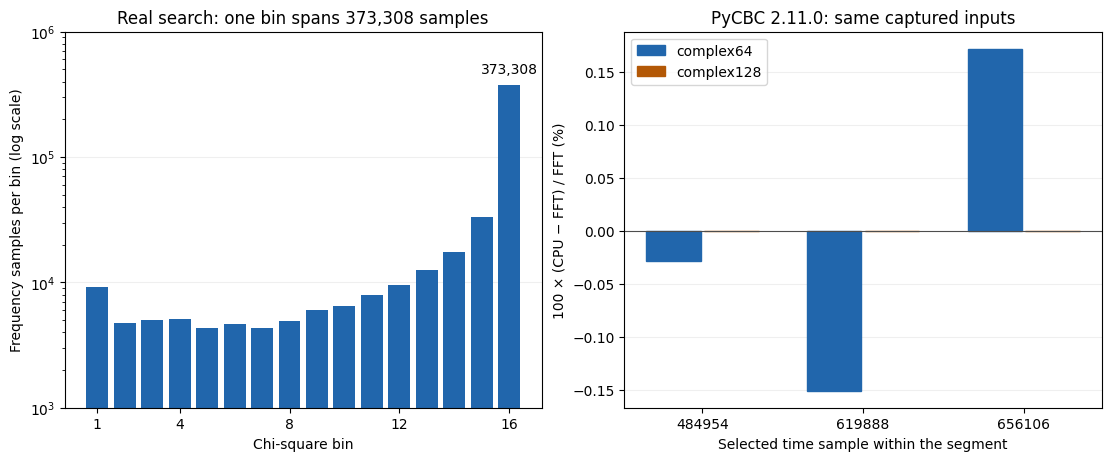

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout='constrained')
ax = axes[0]
ax.bar(np.arange(1, p+1), widths, color='#2166ac')
ax.set(yscale='log', xlabel='Chi-square bin', ylabel='Frequency samples per bin (log scale)',
       title='Real search: one bin spans 373,308 samples', ylim=(1000, 1_000_000))
ax.set_xticks([1, 4, 8, 12, 16])
ax.text(p, widths[-1]*1.25, f'{widths[-1]:,}', ha='center', fontsize=10)
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)

ax = axes[1]
x = np.arange(len(points))
for offset, name, color, hatch in [(-0.18, 'complex64', '#2166ac', ''),
                                   (0.18, 'complex128', '#b35806', '//')]:
    ax.bar(x+offset, error_percent[name], width=0.34, color=color,
           hatch=hatch, label=name, edgecolor=color)
ax.axhline(0, color='0.3', linewidth=0.8)
ax.set(xticks=x, xticklabels=[str(int(t)) for t in points],
       xlabel='Selected time sample within the segment',
       ylabel='100 × (CPU − FFT) / FFT (%)',
       title=f'PyCBC {pycbc.__version__}: same captured inputs')
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)
ax.legend(loc='upper left')
plt.show()

## What this establishes

- An ordinary search of real detector strain produced a bin spanning **373,308 frequency samples**, with **373,307 successive rotations before its final coefficient**. The report's larger maximum, 396,226, came from another observed call.
- Fresh calls to the released **PyCBC 2.11.0** CPU routine still show a discrepancy against two agreeing double-precision reference calculations on these fixed inputs.
- Promoting the correlation reduces the discrepancy here. This does not establish a runtime cost, a complete correction, or a typical error across a science search.
- We have not measured effects on detection sensitivity, ranking, false-alarm rates or a published catalogue. The highlighted point failed the original NewSNR cut.

The original search used MKL for its FFTs. This notebook holds its saved correlation fixed: the comparison concerns the subsequent CPU point calculation. SciPy's FFT is used as an independent reference, not as a replacement search backend.

**Sources:** [PyPI 2.11.0](https://pypi.org/project/PyCBC/2.11.0/), [CPU recurrence](https://github.com/gwastro/pycbc/blob/v2.11.0/pycbc/vetoes/chisq_cpu.pyx), [chi-square wrapper and bin construction](https://github.com/gwastro/pycbc/blob/v2.11.0/pycbc/vetoes/chisq.py), [full report and search provenance](https://github.com/xangma/pycbc/blob/e8b63f56ea444dca7b5ead91ca3a34da7398e3b5/docs/jax_chisq_numerics.rst).